In [1]:
NZ=2396; NX=13601; H=1.25

velmin=1065
velmax=4700

#chosen
fpeak=6

#consequently
h=int(velmin/fpeak/2.5/5)
nz=int(NZ*H/h)+1
nx=int(NX*H/h)+1
print(h,nz,nx)

dt=0.6*h/velmax *0.98
T=5 #time window [s]
nt=int(T/dt)
print(dt,nt)

dt=0.00175
nt=int(T/dt)
print(dt,nt)

ntr=600

14 214 1215
0.0017514893617021278 2854
0.00175 2857


In [2]:
import os
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def write(filename,data,n=(nx,nz)):
    data.T.astype('float32').tofile(filename)

    
def hilb(data,axis=0):
    return np.imag(hilbert(data,axis=axis))

    
def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWD',setup='setup',nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > $out
        
def run_remote(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        #!./run.sh
        print("bash ./run.sh")
    else:
        #!./run.sh > $out
        print(f"bash ./run.sh > {out}")

## Prepare

In [4]:
##code
#!(cd ../../ ; git pull ; git checkout teaching ; make prepare)
#!(cd ../../FWD ; make cleanall ; make)
#!(cd ../../FWI ; make cleanall ; make)
#!gfortran smoothgauss2dfast_zhou.f90 -o smoothgauss2dfast_zhou

In [10]:
# #clone model
# # !wget https://s3.amazonaws.com/open.source.geoscience/open_data/elastic-marmousi/elastic-marmousi-model.tar.gz #https://wiki.seg.org/wiki/AGL_Elastic_Marmousi
# # !tar -xvzf elastic-marmousi-model.tar.gz
# # !(cd ./elastic-marmousi-model/model/ ; for fi in `ls *.tar.gz`; do tar -xvzf $$fi; done)
# !segyread tape=./elastic-marmousi-model/model/MODEL_P-WAVE_VELOCITY_1.25m.segy | sugain bias=0 | sustrip > vp.bin
# !segyread tape=./elastic-marmousi-model/model/MODEL_DENSITY_1.25m.segy | sustrip | farith op=scale scale=1000 > rho.bin  #convert to [kg/m3]

# !unif2 ninf=1 nz=281 nx=1361 v00=2000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=4000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=1 > rho.bin

In [74]:
#chop the water layer
vp = read('vp.bin',(13601,2801)) [405:,:]
rho= read('rho.bin',(13601,2801))[405:,:]

#make Qp model by empirical law
qp = vp**0.5 #leads to a range of ~35--65, small enough to cause instability
qp = vp**0.75 #leads to a range of ~200--550, not yet instability

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(vp)
plt.subplot(1,3,2); imshow(rho)
plt.subplot(1,3,3); imshow(qp)

FileNotFoundError: [Errno 2] No such file or directory: 'vp.bin'

In [17]:
print(vp.shape)

(2396, 13601)


In [38]:
#save to disk
write('vpt.bin',vp)
write('rhot.bin',rho)
write('qpt.bin',qp)

In [61]:
#downsample true models
!make -B true

#make init models
!make -B init

#catenate
!cat vpt.14m   rhot.14m   qpt.14m  > true
!cat vpt.init  rhot.init  qpt.init > init

echo 13.4453
13.4453
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.48/sig will be suppressed
 c'est à dire que les nombres d'onde qui sont plus large que 0.48/sig ont l'amplitude sous 1% du crête. 
 Smooth parameter (0) or its inverse (1) or its inverse square (2)
 Constant topography (>=0) or variant (<0)
  go to the square inverse
  grids points involved il2 il1 =           44          44
  go back from the square inverse
   9.30400666E+10
unisam2 < vpt.smth > vpt.14m \
  nx1=2396  dx1=1.25    nx2=13601  dx2=1.25 \
  n1=214    d1=14      n2=1215   d2=14
echo 13.4453
13.4453
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0

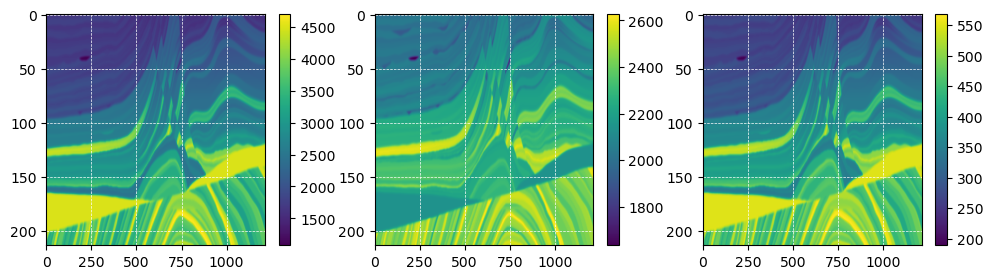

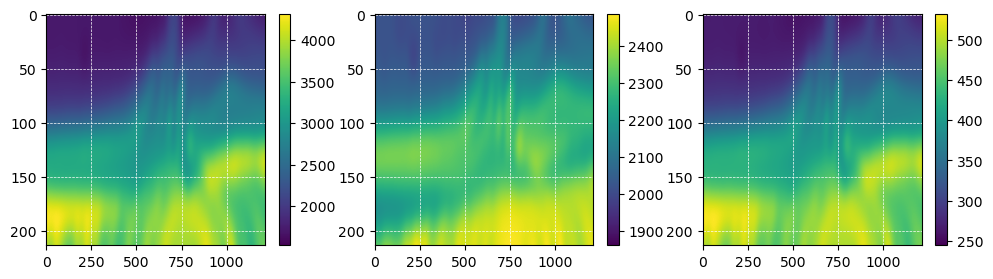

In [75]:
#plot

plt.figure(figsize=(12,3))

true=read('true',(3*nx,nz))
plt.subplot(1,3,1); imshow(true[:,:nx])
plt.subplot(1,3,2); imshow(true[:,nx:2*nx])
plt.subplot(1,3,3); imshow(true[:,2*nx:])

plt.figure(figsize=(12,3))

init=read('init',(3*nx,nz))
plt.subplot(1,3,1); imshow(init[:,:nx])
plt.subplot(1,3,2); imshow(init[:,nx:2*nx])
plt.subplot(1,3,3); imshow(init[:,2*nx:])

In [69]:
#min max of true vp
print(true[:,:nx].min(),true[:,:nx].max())

1078.463 4699.3086


## Observed data

In [70]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 21 Sep 23 08:28 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 09:06:13
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

In [71]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
!echo "NS               1 " >> setup  #Number of Shots
#!echo "SNAPSHOT         p" >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 21 Sep 23 08:28 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 09:06:47
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

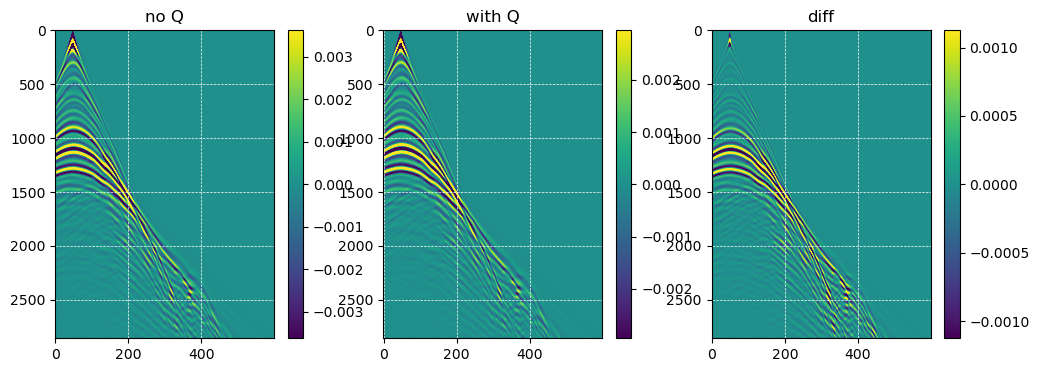

In [74]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs_noQ/Ru_Shot0001.su'),perc=98,title='no Q')
plt.subplot(1,3,2); imshow(read_su('results_obs/Ru_Shot0001.su'    ),perc=98,title='with Q')
plt.subplot(1,3,3); imshow(read_su('results_obs_noQ/Ru_Shot0001.su')-read_su('results_obs/Ru_Shot0001.su'),perc=98,title='diff')

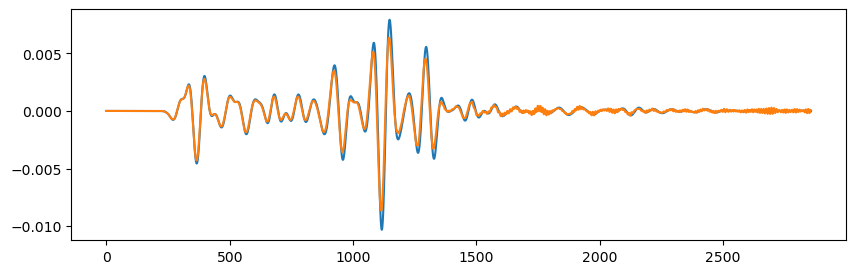

In [73]:
plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_noQ/Ru_Shot0001.su')[:,75])
plt.plot(read_su('results_obs/Ru_Shot0001.su'    )[:,75])

## FWI gradient

In [3]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 51 Sep 23 09:10 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 11:58:07
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef|

 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 DATA_NORM (DNORM) is NOT found, take default: L2
 SU data write success.
 SU data write success.
 ----  Solving adjoint eqn & xcorrelate  ----
 it----        2500
 fld_reA minmax values:  -50945.3398       64096.2422    
 fld_imA minmax values:  -74228.7031       47206.2891    
 fld_reU minmax values:  -18.2788391       17.0306530    
 fld_imU minmax values:  -11.4649000       21.2499123    
 it----        2000
 fld_reA minmax values:  -424353.812       284471.406    
 fld_imA minmax values:  -463791.656       216129.703    
 fld_reU minmax values:  -35.7550545       79.5741806    
 fld_imU minmax values:  -63.3434258       67.4496002    
 it----        1500
 fld_reA minmax values:  -491199.250       315072.156    
 fld_imA minmax values:  -521683.312       345181.594    
 fld_reU minmax values:  -42.8826256       104.681671    
 fl

In [4]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 51 Sep 23 09:10 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 11:59:14
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *

 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 DATA_NORM (DNORM) is NOT found, take default: L2
 SU data write success.
 SU data write success.
 ----  Solving adjoint eqn & xcorrelate  ----
 it----        2500
 fld_reA minmax values:  -37041.5938       49709.0312    
 fld_imA minmax values:  -63708.5117       34577.4141    
 fld_reU minmax values:  -13.2445660       13.0363598    
 fld_imU minmax values:  -7.66626644       16.1727619    
 it----        2000
 fld_reA minmax values:  -333930.875       218753.859    
 fld_imA minmax values:  -367570.625       163131.641    
 fld_reU minmax values:  -25.7796001       61.7964935    
 fld_imU minmax values:  -49.4217834       50.4316292    
 it----        1500
 fld_reA minmax values:  -401679.500       248257.531    
 fld_imA minmax values:  -425734.656       274885.594    
 fld_reU minmax values:  -33.1158066       85.6193008    
 fl

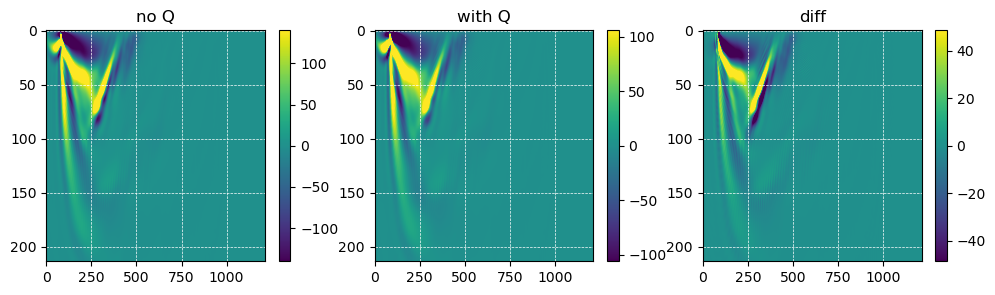

In [5]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results_grad_noQ/qp0%pg'),perc=98,title='no Q')
plt.subplot(1,3,2); imshow(read('results_grad/qp0%pg'    ),perc=98,title='with Q')
plt.subplot(1,3,3); imshow(read('results_grad_noQ/qp0%pg')-read('results_grad/qp0%pg'),perc=98,title='diff')

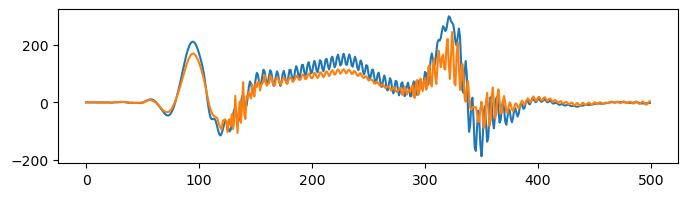

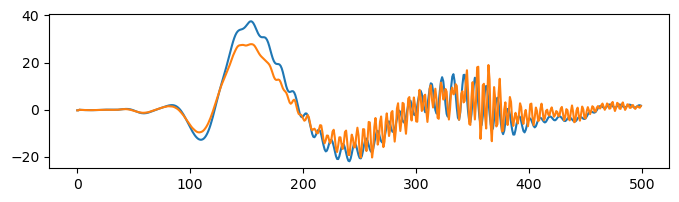

In [8]:
plt.figure(figsize=(8,2))
plt.plot(read('results_grad_noQ/qp0%pg')[50,:500],label='no Q')
plt.plot(read('results_grad/qp0%pg'    )[50,:500],label='with Q')

plt.figure(figsize=(8,2))
plt.plot(read('results_grad_noQ/qp0%pg')[150,:500],label='no Q')
plt.plot(read('results_grad/qp0%pg'    )[150,:500],label='with Q')

## Multiple shots

### data

In [11]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
run_remote(np=36,nthreads=1,out='out')

bash ./run.sh > out_obs_noQ


In [12]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 21 Sep 23 10:18 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: f5d62ae
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 10:24:52
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diago

In [13]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
run_remote(np=36,nthreads=1,out='out')

bash ./run.sh > out


In [14]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 21 Sep 23 10:18 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: f5d62ae
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 10:28:15
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -

### gradient

In [26]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
#8min for one gradient

bash ./run.sh > out


In [28]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 51 Sep 23 10:18 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: f5d62ae
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 11:26:27
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ

In [31]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
!echo "SMOOTHING        Laplacian "  >> setup
!echo "LAP_FRAC        '0.5 1 1' "  >> setup
!echo "PRECO            z^2      "  >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

bash ./run.sh > out


In [32]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/weizhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 weizhou weizhou 51 Sep 23 10:18 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: f5d62ae
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 11:35:43
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *

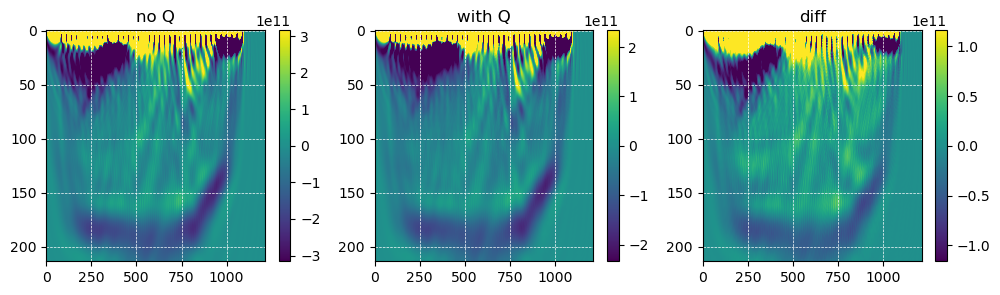

In [38]:
grad0=read('results_grad_noQ/correlate_gradient',(2*nx,nz)) [:,nx:]
grad1=read('results_grad/correlate_gradient'    ,(2*nx,nz)) [:,nx:]

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad0,perc=90,title='no Q')
plt.subplot(1,3,2); imshow(grad1,perc=90,title='with Q')
plt.subplot(1,3,3); imshow(grad0-grad1,perc=90,title='diff')

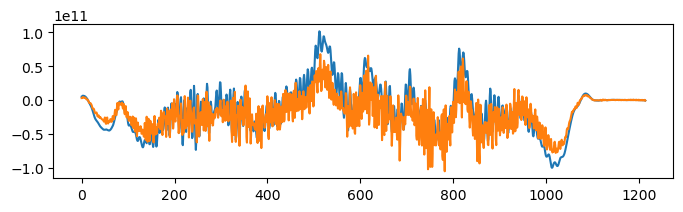

In [46]:
plt.figure(figsize=(8,2))
plt.plot(grad0[100,:],label='no Q')
plt.plot(grad1[100,:],label='with Q')

In [59]:
zpow=np.zeros((nz,nx))

for iz in range(nz):
    z = (iz-1)*h/1e3
    zpow[iz,:] = z

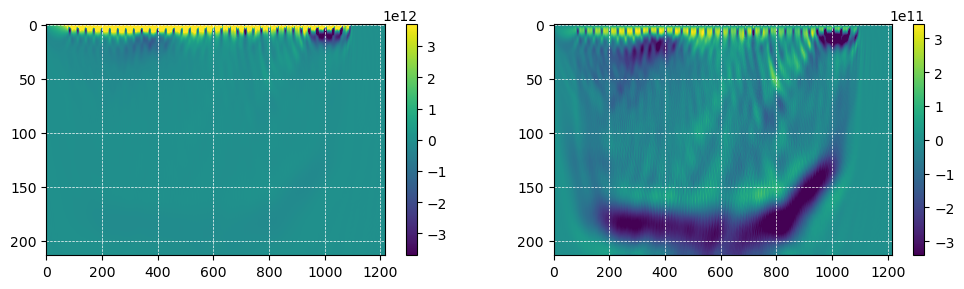

In [61]:
plt.figure(figsize=(12,3))
plt.subplot(1,2,1); imshow(grad1,perc=98)
plt.subplot(1,2,2); imshow(grad1*zpow,perc=98)

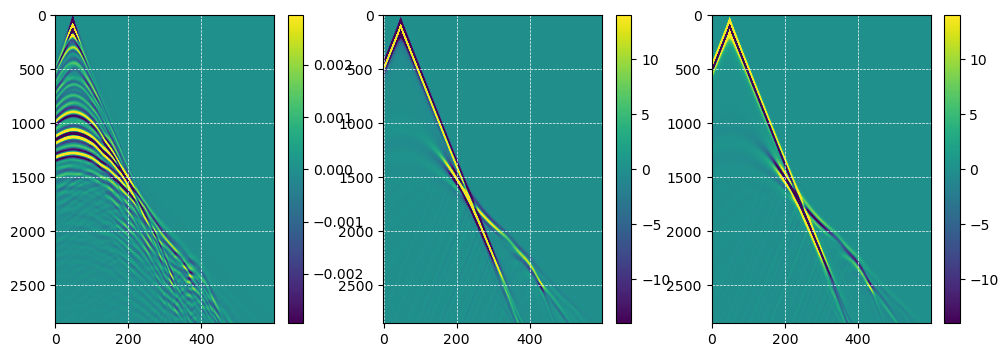

In [43]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_grad_noQ/Ru_Shot0001.su'  ),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_grad_noQ/dadj_Shot0001.su'), perc=98)

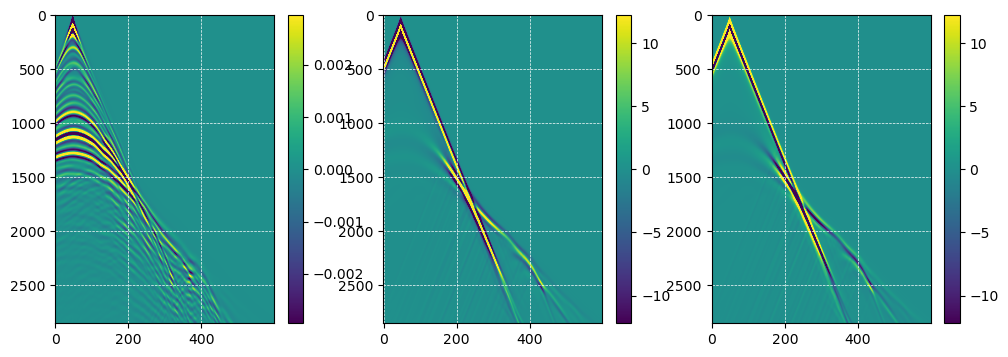

In [42]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_grad/Ru_Shot0001.su'  ),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_grad/dadj_Shot0001.su'), perc=98)

## FWI iterations

In [64]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results " >> setup
!echo "SMOOTHING        Laplacian "  >> setup
!echo "LAP_FRAC        '0.5 0.5 0.5' "  >> setup
!echo "PRECO            z^0.5        "  >> setup
!echo "JOB              optimization " >> setup
run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')

bash ./run.sh > out


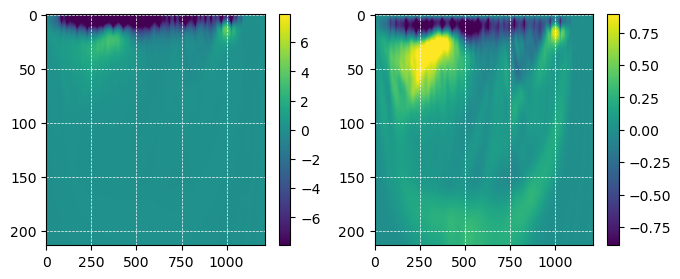

In [72]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/qp0%pg'),     perc=98)
plt.subplot(1,3,2); imshow(read('results/qp0%pg')*zpow,perc=98)

comments: zpow is insufficient..

In [70]:
!cat results/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =  120
     Max linesearches allowed =   12
     Max gradients allowed    =  150
     Linesearch scaler        =4.75705339E-04
     Initial gradient L1norm (║g0║₁)  =7.1536E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 4.4711E+01 100.000  100.000     -2.50E-01
            1      2  1.00E+00       4.3553E+01                      -2.20E-01   T T
     1             2                 4.3553E+01  97.410   89.175     -1.80E+00
 ----------------------------------------------------------------------------------------
   

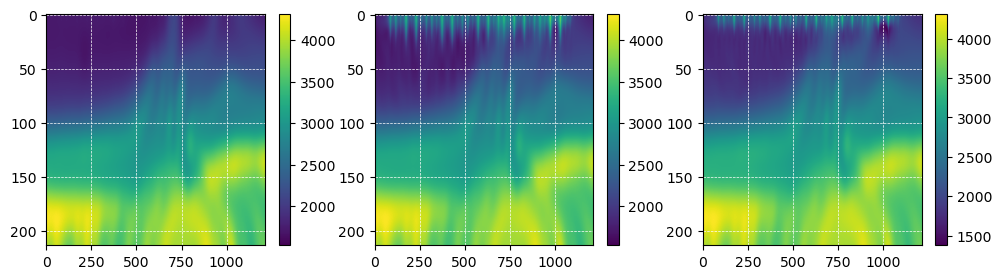

In [67]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/model_Iter1'))
plt.subplot(1,3,2); imshow(read('results/model_Iter4'))
plt.subplot(1,3,3); imshow(read('results/model_Iter7'))

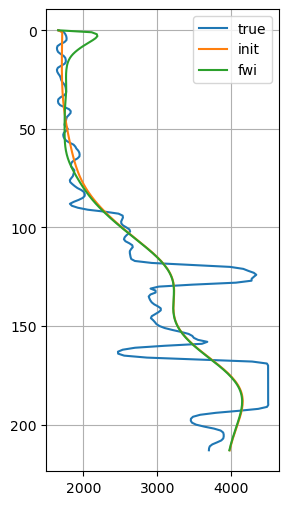

In [79]:
iz=np.arange(nz)

vpfwi=read('results/model_Iter7')

plt.figure(figsize=(3,6))
plt.plot(true[:,250],iz,label='true')
plt.plot(init[:,250],iz,label='init')
plt.plot(vpfwi[:,250],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()